In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [43]:
np.random.seed(42)

n = 500

age = np.random.randint(18, 60, n)
income = np.random.randint(20000, 150000, n)
spending_score = np.random.randint(1, 101, n)
previous_purchases = np.random.randint(0, 21, n)

purchase_score = (
    0.03 * income
    + 2 * spending_score
    + 50 * previous_purchases
    - 100 * age
)

purchase = (purchase_score > np.median(purchase_score)).astype(int)

df = pd.DataFrame({
    "Age": age,
    "Income": income,
    "SpendingScore": spending_score,
    "PreviousPurchases": previous_purchases,
    "Purchase": purchase
})




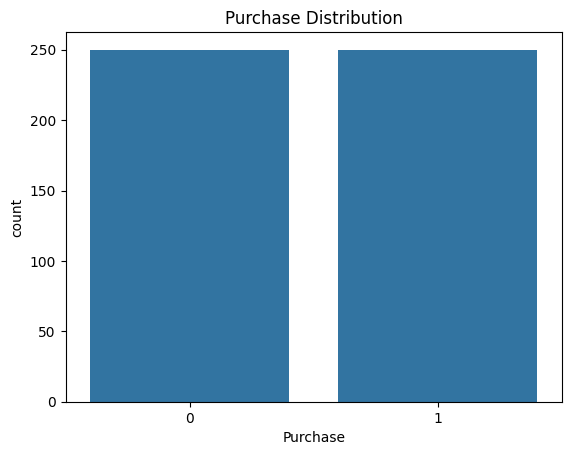

In [31]:
sns.countplot(x="Purchase", data=df)

plt.title("Purchase Distribution")
plt.show()

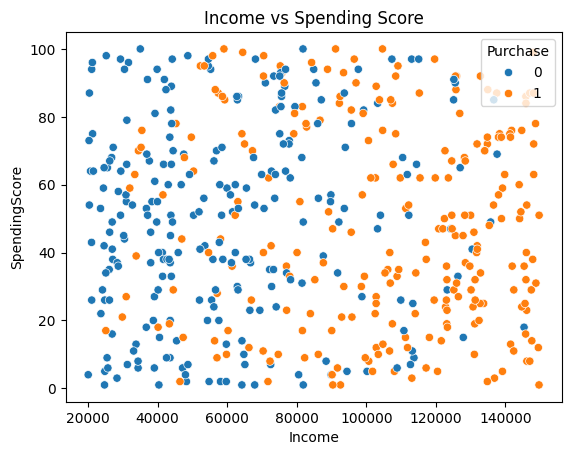

In [32]:
sns.scatterplot(
    x="Income",
    y="SpendingScore",
    hue="Purchase",
    data=df
)

plt.title("Income vs Spending Score")
plt.show()

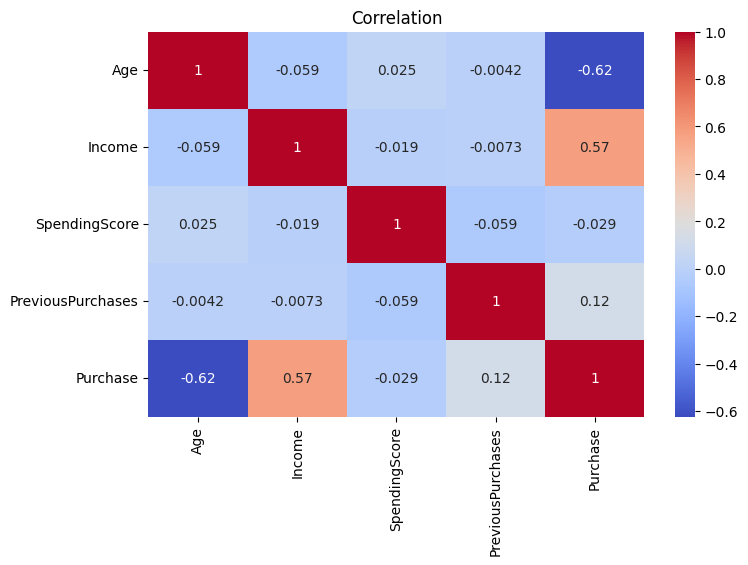

In [45]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation")
plt.show()

In [46]:
X = df.drop("Purchase", axis=1)

y = df["Purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [35]:
y_pred = knn.predict(X_test_scaled)

In [36]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

print(cm)

Accuracy: 0.94
[[46  4]
 [ 2 48]]


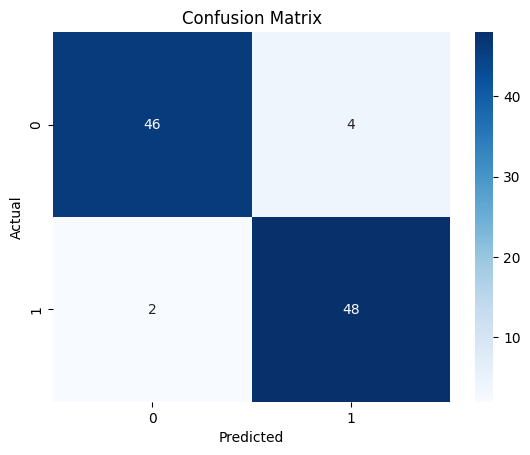

In [37]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [38]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        50
           1       0.92      0.96      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



In [39]:
k_values = range(1, 31)

accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        X_train_scaled,
        y_train
    )

    y_pred_k = knn.predict(
        X_test_scaled
    )

    accuracies.append(
        accuracy_score(
            y_test,
            y_pred_k
        )
    )

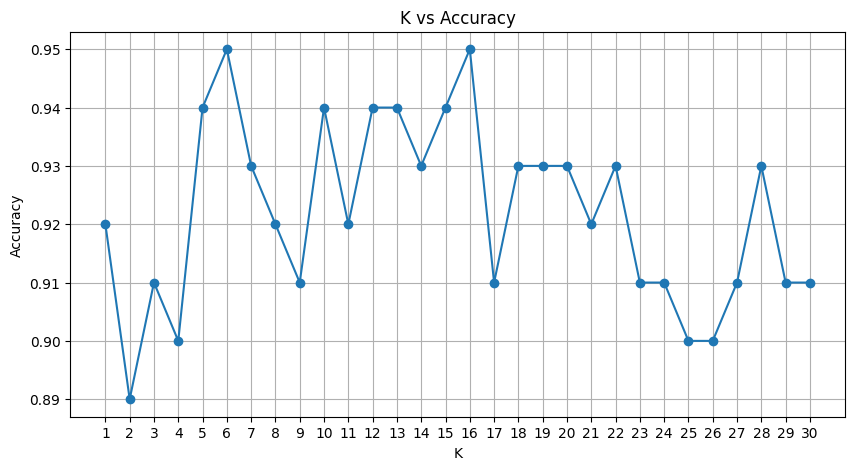

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Accuracy")

plt.title("K vs Accuracy")

plt.xticks(k_values)

plt.grid()

plt.show()

In [41]:
final_model = KNeighborsClassifier(
    n_neighbors=7
)

final_model.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=7)

In [42]:
new_customer = pd.DataFrame({
    "Age": [25],
    "Income": [70000],
    "SpendingScore": [90],
    "PreviousPurchases": [10]
})

new_customer_scaled = scaler.transform(
    new_customer
)

prediction = final_model.predict(
    new_customer_scaled
)

print(prediction)

[1]
